<Figure size 1000x600 with 0 Axes>

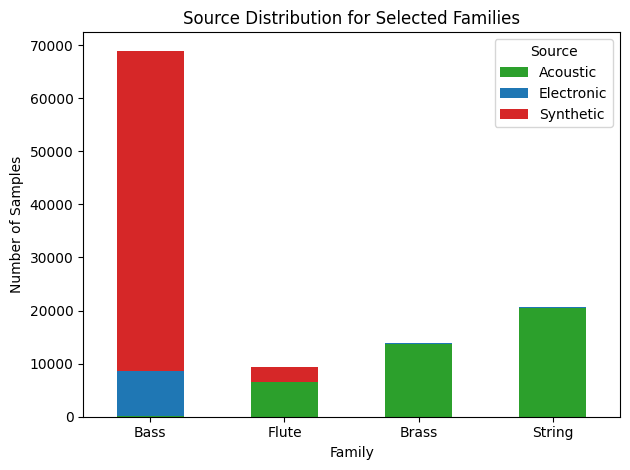

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
source_data = {
    'Family': ['Bass', 'Flute', 'Brass', 'String'],
    'Acoustic': [200, 6572, 13760, 20510],
    'Electronic': [8387, 35, 70, 84],
    'Synthetic': [60368, 2816, 0, 0]
}
df_source = pd.DataFrame(source_data).set_index('Family')

plt.figure(figsize=(10, 6))
df_source.plot(kind='bar', stacked=True, color=['#2ca02c', '#1f77b4', '#d62728'])
plt.title('Source Distribution for Selected Families')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend(title='Source')
plt.tight_layout()
plt.savefig('source_distribution.png')

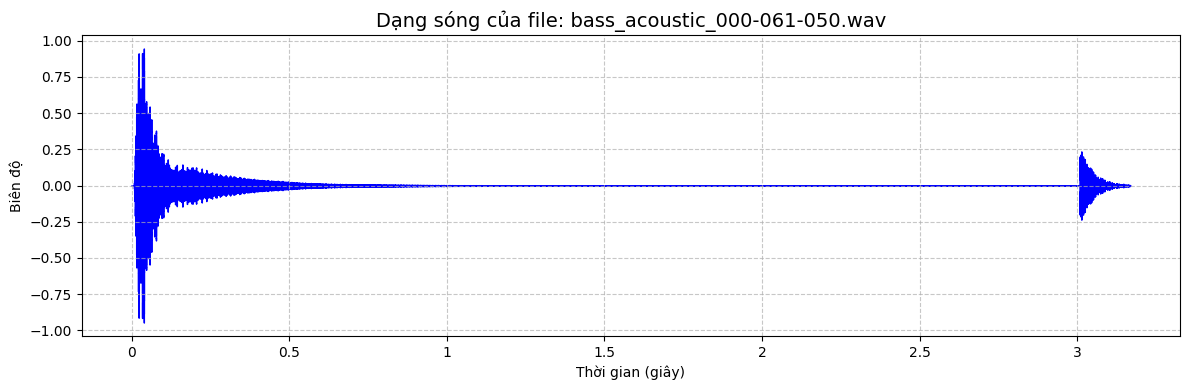

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def plot_waveform(file_path):
    y, sr = librosa.load(file_path, sr=None)

    plt.figure(figsize=(12, 4))

    librosa.display.waveshow(y, sr=sr, color='blue')

    plt.title(f'Dạng sóng của file: {file_path.split("/")[-1]}', fontsize=14)
    plt.xlabel('Thời gian (giây)')
    plt.ylabel('Biên độ')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

file_audio = "/kaggle/input/waveeeeeeeee/bass_acoustic_000-061-050.wav"
plot_waveform(file_audio) 

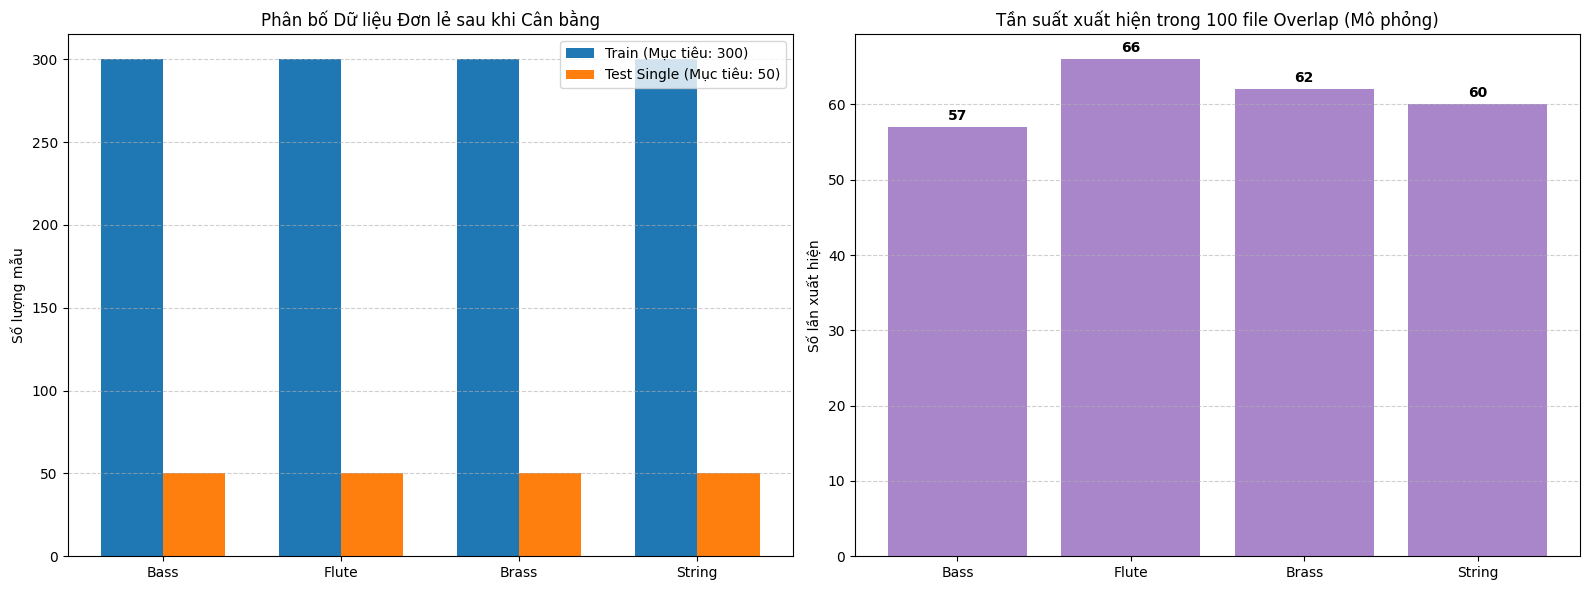

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter

families = ['Bass', 'Flute', 'Brass', 'String']
train_goal = 300
test_goal = 50
num_overlaps = 100

df_single = pd.DataFrame({
    'Nhạc cụ': families,
    'Train': [train_goal] * 4,
    'Test Single': [test_goal] * 4
})

np.random.seed(42) 
overlap_list = []
for _ in range(num_overlaps):
    n = np.random.choice([2, 3])
    picked = np.random.choice(families, n, replace=False)
    overlap_list.extend(picked)

overlap_counts = Counter(overlap_list)
df_overlap = pd.DataFrame({
    'Nhạc cụ': families,
    'Tần suất': [overlap_counts[f] for f in families]
})

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(families))
width = 0.35
ax[0].bar(x - width/2, df_single['Train'], width, label='Train (Mục tiêu: 300)', color='#1f77b4')
ax[0].bar(x + width/2, df_single['Test Single'], width, label='Test Single (Mục tiêu: 50)', color='#ff7f0e')
ax[0].set_title('Phân bố Dữ liệu Đơn lẻ sau khi Cân bằng')
ax[0].set_ylabel('Số lượng mẫu')
ax[0].set_xticks(x)
ax[0].set_xticklabels(families)
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

bars = ax[1].bar(df_overlap['Nhạc cụ'], df_overlap['Tần suất'], color='#9467bd', alpha=0.8)
ax[1].set_title(f'Tần suất xuất hiện trong {num_overlaps} file Overlap (Mô phỏng)')
ax[1].set_ylabel('Số lần xuất hiện')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    ax[1].annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), 
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

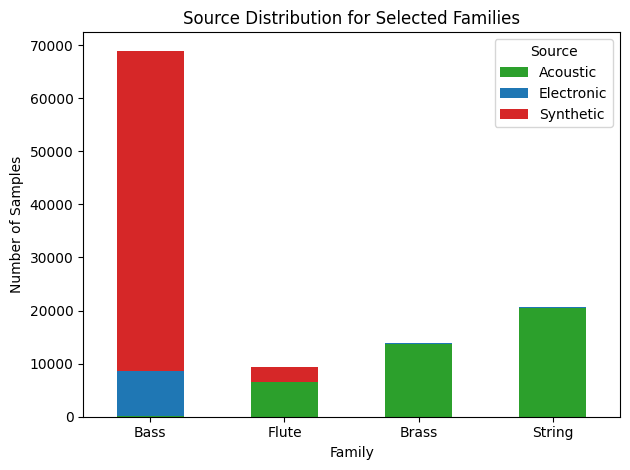

In [11]:
source_data = {
    'Family': ['Bass', 'Flute', 'Brass', 'String'],
    'Acoustic': [200, 6572, 13760, 20510],
    'Electronic': [8387, 35, 70, 84],
    'Synthetic': [60368, 2816, 0, 0]
}
df_source = pd.DataFrame(source_data).set_index('Family')

plt.figure(figsize=(10, 6))
df_source.plot(kind='bar', stacked=True, color=['#2ca02c', '#1f77b4', '#d62728'])
plt.title('Source Distribution for Selected Families')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend(title='Source')
plt.tight_layout()
plt.savefig('source_distribution.png')